# AWBS - Project 1
author: Mateusz Domalewski

group: 2

index: 288761

In [1]:
DATA_2023 = "./data_202302/"
DATA_2021 = "./data_202102/"

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

## Business understanding

### Determining objectives

- Analysis of Internet traffic performance
- Account the download and upload packages
- Incorporate establishing relationships (influences) between parameters refering to Internet traffic performance

### Data mining goals

- Compare Internet traffic performance of dataset from 2023 with the data from 2021
- Clearly present tasks and results. Use tables, charts, diagrams.
- Provide comparative analysis for different prediction algorithms.
- Provide conclusions

### Project Plan

- perform a prediction of a selected parameter related to the performance of Internet traffic
- propose three different, appropriate models for prediction, present their synthetic characteristics, justification for use, limitations, selected set of parameters and their values.


## Data understanding

### Collecting initial data

|dataset|year|link|
|---|---|---|
|data_raw_2023_02| 2023 | https://data.fcc.gov/download/measuring-broadband-america/2023/data-raw-2023-feb.tar.gz |
| data_raw_2021_02 | 2021 | https://data.fcc.gov/download/measuring-broadband-america/2021/data-raw-2021-feb.tar.gz |

### Describing data

**2023**

In [2]:
import polars as pl

upload_2023 = pl.read_csv(DATA_2023+"curr_lct_ul.csv")
download_2023 = pl.read_csv(DATA_2023+"curr_lct_dl.csv")

**upload 2023**

In [3]:
upload_2023.describe()

statistic,unit_id,ddate,dtime,target,address,packets_received,packets_sent,packet_size,bytes_total,duration,bytes_sec,error_code,successes,failures
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",869043.0,"""869043""","""869043""","""869043""","""869043""",869043.0,869043.0,869043.0,869043.0,869043.0,869043.0,"""869043""",869043.0,869043.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0
"""mean""",2.2472e7,null,null,null,null,91.470139,99.272878,1400.0,128058.194589,308216.803378,6.1957e6,null,0.992729,0.007271
"""std""",2.5433e7,null,null,null,null,20.589431,8.49609,0.0,28825.203781,474150.203915,1.4260e7,null,0.084961,0.084961
"""min""",386.0,"""2023-01-31""","""2023-02-01 00:00:03""","""sk-1.uhnet.net""","""0.0.0.0""",0.0,0.0,1400.0,0.0,0.0,0.0,"""EXPORT_ERROR""",0.0,0.0
"""25%""",805922.0,null,null,null,null,100.0,100.0,1400.0,140000.0,19884.0,224069.0,null,1.0,0.0
"""50%""",4.172709e6,null,null,null,null,100.0,100.0,1400.0,140000.0,62963.0,1.95209e6,null,1.0,0.0
"""75%""",3.9486057e7,null,null,null,null,100.0,100.0,1400.0,140000.0,442474.0,6.599104e6,null,1.0,0.0
"""max""",9.3007349e7,"""2023-02-28""","""2023-02-28 23:59:56""","""sp2-vm-newyork-us.samknows.com""","""74.40.74.101""",100.0,100.0,1400.0,140000.0,9.254213e6,7.13207547e8,"""ZERO_RECEIVED_SERVER""",1.0,1.0


In [4]:
up_avgs = upload_2023.group_by(["target"], maintain_order=True).agg(pl.col("packets_sent").mean().name.suffix("_mean"), pl.col("packets_sent").std().name.suffix("_stdev"), (pl.col("successes").mean() * 100).name.suffix("_pct"), (pl.col("failures").mean() * 100).name.suffix("_pct") )

up_avgs = up_avgs.sort("target").fill_null(0.0)

up_avgs

target,packets_sent_mean,packets_sent_stdev,successes_pct,failures_pct
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",99.183511,8.999462,99.183511,0.816489
"""sp1-vm-ashburn-us.samknows.com""",99.187515,8.977155,99.187515,0.812485
"""sp1-vm-atlanta-us.samknows.com""",99.509582,6.98583,99.509582,0.490418
"""sp1-vm-chicago-us.samknows.com""",99.143512,9.214987,99.143512,0.856488
"""sp1-vm-dallas-us.samknows.com""",99.18698,8.980102,99.18698,0.81302
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",98.990189,9.998188,98.990189,1.009811
"""sp1-vm-seattle-us.samknows.com""",99.565673,6.576074,99.565673,0.434327
"""sp2-vm-ashburn-us.samknows.com""",92.857143,26.226526,92.857143,7.142857


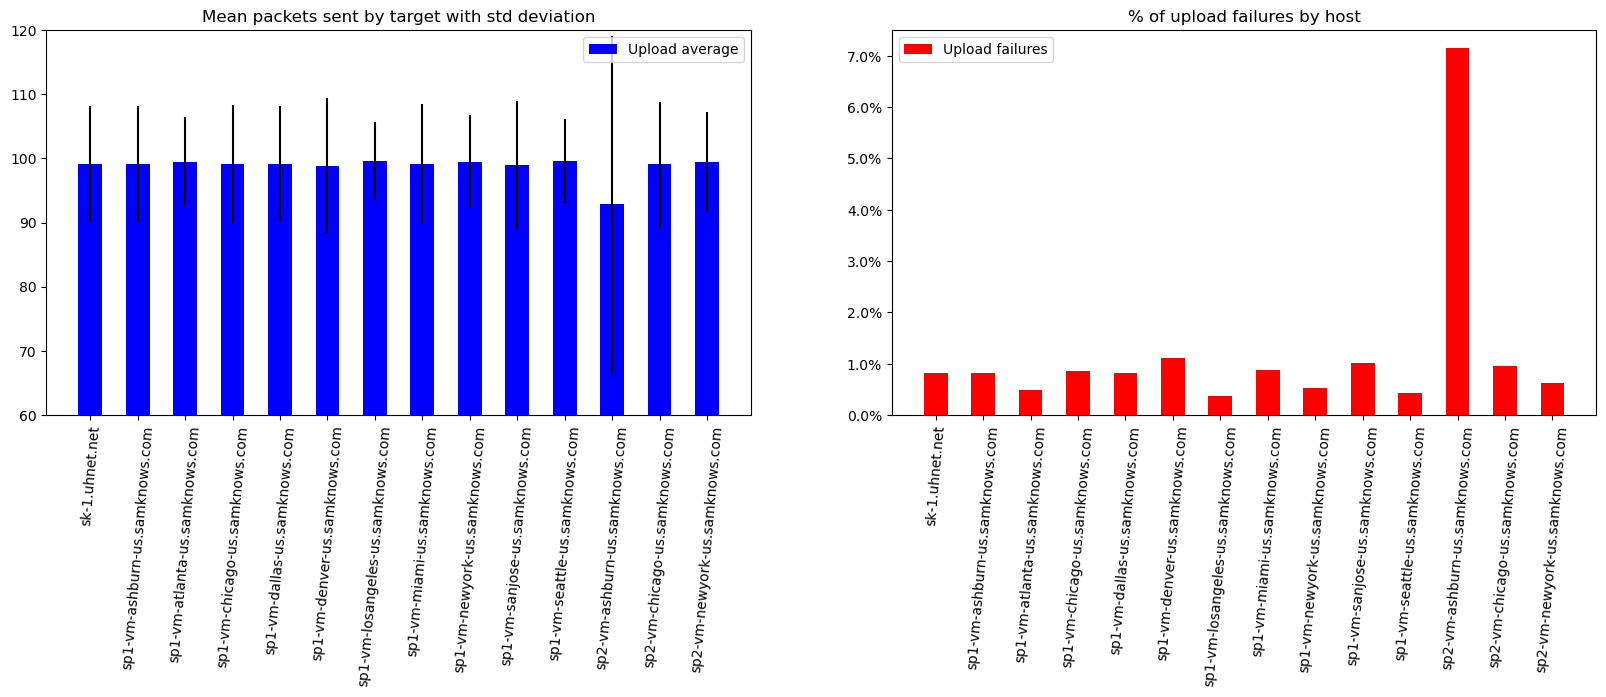

In [5]:
targets, up_means, up_stdev, up_oks, up_fails = up_avgs.to_numpy().transpose()


fig, ax = plt.subplots(1, 2, figsize=[20,5])

# means
ax[0].bar(targets, up_means, width=0.5, yerr=up_stdev, label="Upload average", color="blue")
ax[0].set_ylim(60.0, 120.0)
ax[0].set_title("Mean packets sent by target with std deviation")

# failures

ax[1].bar(targets, up_fails, width=0.5, label="Upload failures", color="red")
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter())
ax[1].set_title("% of upload failures by host")

for i in range(len(ax)):
    ax[i].legend()
    ax[i].autoscale_view()
    ax[i].tick_params(axis="x", rotation=85)

plt.show()

In [6]:
errors = upload_2023.group_by(["target", "error_code"]).agg(pl.col("error_code").count().alias("amount"))

errors = errors.join(upload_2023.group_by("target").agg(pl.col("failures").sum().alias("total")), how="left", on="target")

errors = errors.with_columns(amount_pct = pl.col("amount") * 100 / pl.col("total"))

errors = errors.pivot(on="error_code", index="target", values="amount_pct").drop("NO_ERROR").fill_null(0.0).sort("target")

errors

target,ZERO_RECEIVED_SERVER,TCP_CONNECT,JSON_PARSE_ERROR,EXPORT_ERROR,RCV_FAILED,SEND_FAILED,TCP_RECV
str,f64,f64,f64,f64,f64,f64,f64
"""sk-1.uhnet.net""",15.853659,52.439024,2.439024,0.0,29.268293,0.0,0.0
"""sp1-vm-ashburn-us.samknows.com""",1.091405,82.946794,2.18281,0.0,6.548431,7.230559,0.0
"""sp1-vm-atlanta-us.samknows.com""",2.941176,68.907563,3.781513,0.210084,10.714286,13.445378,0.0
"""sp1-vm-chicago-us.samknows.com""",1.927195,71.627409,2.35546,0.0,3.640257,20.449679,0.0
"""sp1-vm-dallas-us.samknows.com""",2.752294,69.174312,15.779817,0.0,10.642202,1.651376,0.0
…,…,…,…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",3.791469,28.672986,53.317536,0.0,8.056872,6.161137,0.0
"""sp1-vm-seattle-us.samknows.com""",6.382979,75.531915,8.865248,0.0,9.219858,0.0,0.0
"""sp2-vm-ashburn-us.samknows.com""",50.0,0.0,0.0,0.0,50.0,0.0,0.0


14


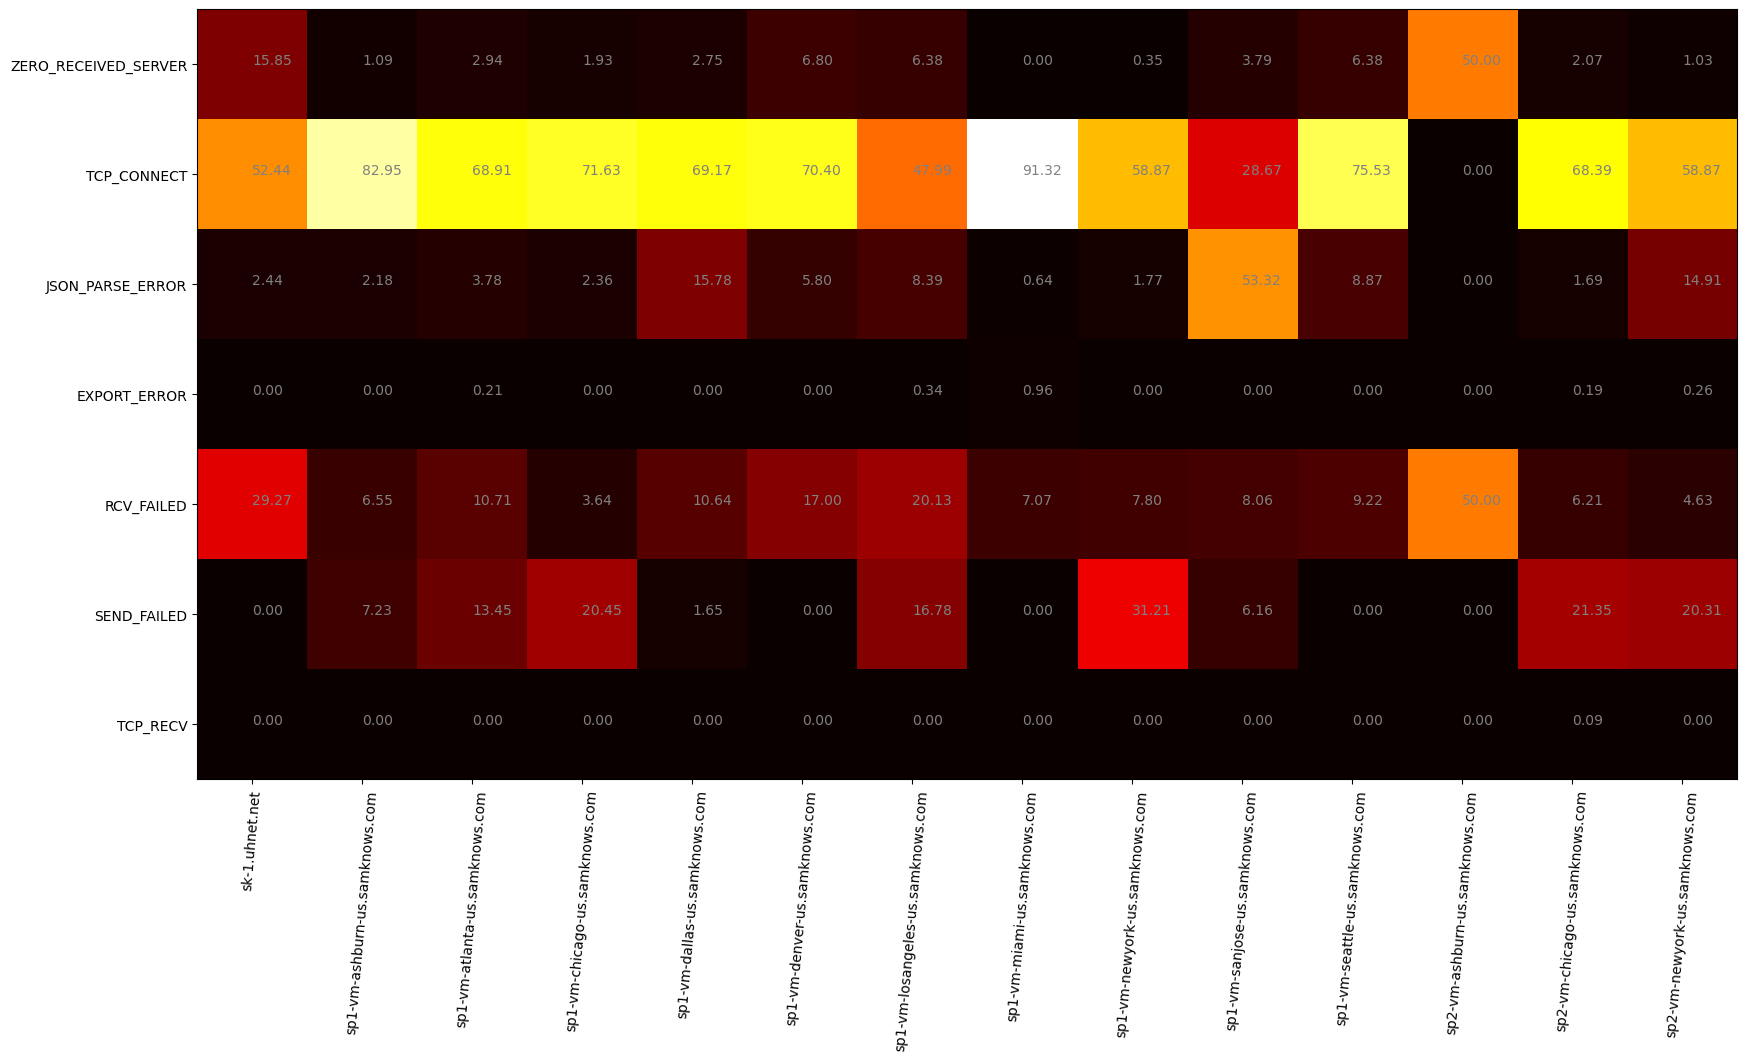

In [7]:
err_types = errors.columns[1:]

targets = errors.to_numpy().transpose()
values = targets[1:].astype(float)
targets = targets[0]

print(len(targets))

fig, ax = plt.subplots(figsize = [25, 10])
ax.imshow(values, cmap="hot")
ax.set_xticks(range(len(targets)), labels=targets, rotation=85)
ax.set_yticks(range(len(err_types)), labels=err_types)

for x in range(len(targets)):
    for y in range(len(err_types)):
        ax.text(x, y, f"{values[y][x]:.2f}", color="gray")

plt.show()

**Download 2023**

**upload 2023**

In [8]:
download_2023.describe()

statistic,unit_id,ddate,dtime,target,address,packets_received,packets_sent,packet_size,bytes_total,duration,bytes_sec,error_code,successes,failures
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",869701.0,"""869701""","""869701""","""869701""","""869701""",869701.0,869701.0,869701.0,869701.0,869701.0,869701.0,"""869701""",869701.0,869701.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0
"""mean""",2.2410e7,null,null,null,null,86.66543,99.667242,1400.0,121331.60178,33574.694549,3.1210e7,null,0.996672,0.003328
"""std""",2.5417e7,null,null,null,null,20.926162,5.758916,0.0,29296.626978,107545.596092,3.5901e7,null,0.057589,0.057589
"""min""",386.0,"""2023-01-31""","""2023-02-01 00:00:00""","""sk-1.uhnet.net""","""0.0.0.0""",0.0,0.0,1400.0,0.0,0.0,0.0,"""NO_ERROR""",0.0,0.0
"""25%""",805804.0,null,null,null,null,77.0,100.0,1400.0,107800.0,5606.0,4.770858e6,null,1.0,0.0
"""50%""",4.172669e6,null,null,null,null,100.0,100.0,1400.0,140000.0,9491.0,1.371387e7,null,1.0,0.0
"""75%""",3.9486017e7,null,null,null,null,100.0,100.0,1400.0,140000.0,23817.0,4.5768056e7,null,1.0,0.0
"""max""",9.3007349e7,"""2023-02-28""","""2023-02-28 23:59:59""","""sp2-vm-newyork-us.samknows.com""","""96.99.224.233""",100.0,100.0,1400.0,140000.0,3.004544e6,3.248e8,"""ZERO_SENT_SERVER""",1.0,1.0


In [9]:
dw_avgs = download_2023.group_by(["target"], maintain_order=True).agg(pl.col("packets_received").mean().name.suffix("_mean"), pl.col("packets_sent").std().name.suffix("_stdev"), (pl.col("successes").mean() * 100).name.suffix("_pct"), (pl.col("failures").mean() * 100).name.suffix("_pct") )

dw_avgs = dw_avgs.sort("target").fill_null(0.0)

dw_avgs

target,packets_received_mean,packets_sent_stdev,successes_pct,failures_pct
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",91.126478,6.960701,99.513164,0.486836
"""sp1-vm-ashburn-us.samknows.com""",89.157478,5.456777,99.701347,0.298653
"""sp1-vm-atlanta-us.samknows.com""",87.476392,5.787542,99.663918,0.336082
"""sp1-vm-chicago-us.samknows.com""",84.214081,5.690691,99.675108,0.324892
"""sp1-vm-dallas-us.samknows.com""",88.259337,5.370254,99.710772,0.289228
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",90.522035,9.42453,99.103771,0.896229
"""sp1-vm-seattle-us.samknows.com""",83.70247,5.597693,99.685675,0.314325
"""sp2-vm-ashburn-us.samknows.com""",85.392857,0.0,100.0,0.0


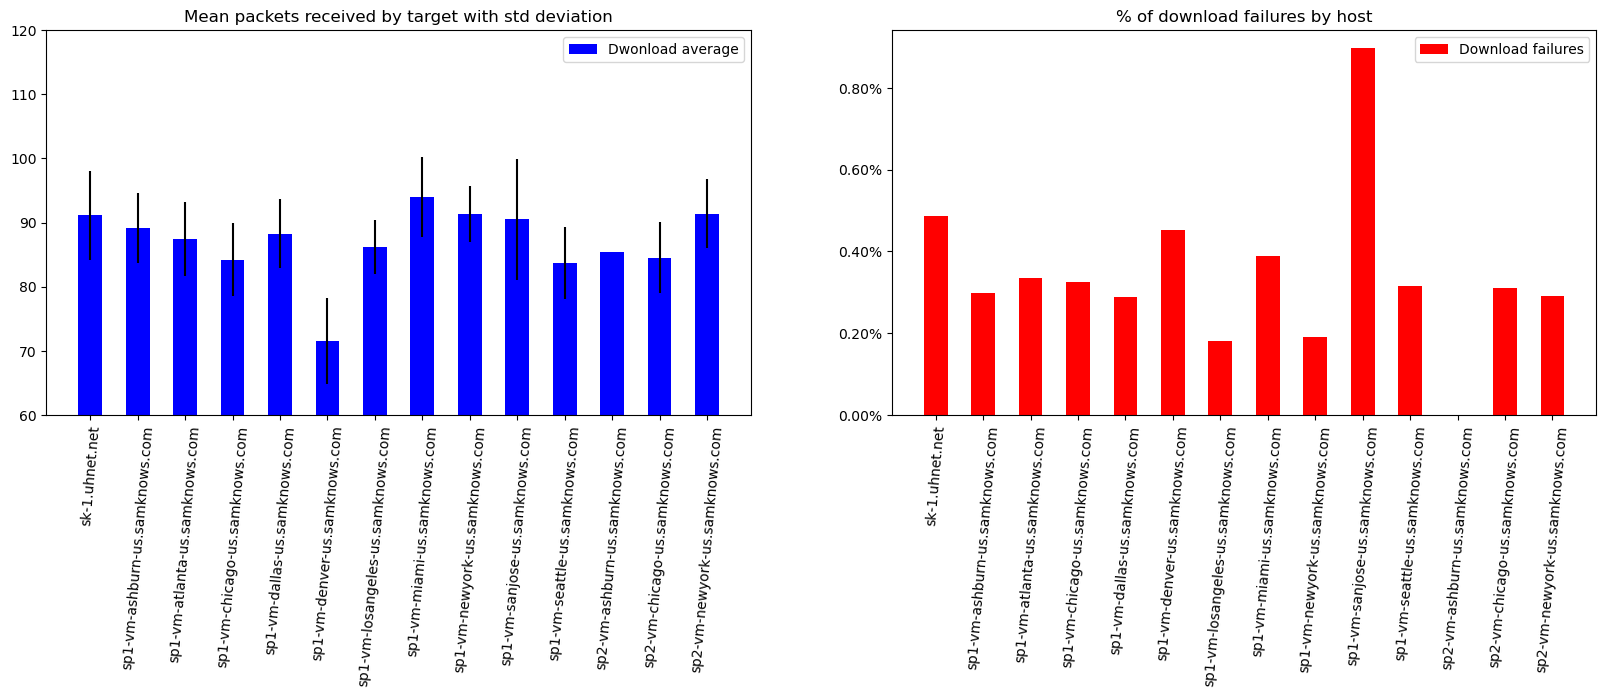

In [10]:
targets, dw_means, dw_stdev, dw_oks, dw_fails = dw_avgs.to_numpy().transpose()


fig, ax = plt.subplots(1, 2, figsize=[20,5])

# means
ax[0].bar(targets, dw_means, width=0.5, yerr=dw_stdev, label="Dwonload average", color="blue")
ax[0].set_ylim(60.0, 120.0)
ax[0].set_title("Mean packets received by target with std deviation")

# failures

ax[1].bar(targets, dw_fails, width=0.5, label="Download failures", color="red")
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter())
ax[1].set_title("% of download failures by host")

for i in range(len(ax)):
    ax[i].legend()
    ax[i].autoscale_view()
    ax[i].tick_params(axis="x", rotation=85)

plt.show()

In [11]:
errors = download_2023.group_by(["target", "error_code"]).agg(pl.col("error_code").count().alias("amount"))

errors = errors.join(upload_2023.group_by("target").agg(pl.col("failures").sum().alias("total")), how="left", on="target")

errors = errors.with_columns(amount_pct = pl.col("amount") * 100 / pl.col("total"))

errors = errors.pivot(on="error_code", index="target", values="amount_pct").drop("NO_ERROR").fill_null(0.0).sort("target")

errors

target,TCP_CONNECT,ZERO_SENT_SERVER,RCV_FAILED,TCP_RECV
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",50.0,1.219512,8.536585,0.0
"""sp1-vm-ashburn-us.samknows.com""",34.652115,0.545703,1.637108,0.0
"""sp1-vm-atlanta-us.samknows.com""",59.663866,4.621849,4.201681,0.0
"""sp1-vm-chicago-us.samknows.com""",34.689507,1.820128,1.498929,0.0
"""sp1-vm-dallas-us.samknows.com""",28.807339,2.93578,3.853211,0.0
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",32.938389,51.421801,4.50237,0.0
"""sp1-vm-seattle-us.samknows.com""",66.312057,1.41844,4.609929,0.0
"""sp2-vm-ashburn-us.samknows.com""",0.0,0.0,0.0,0.0


14


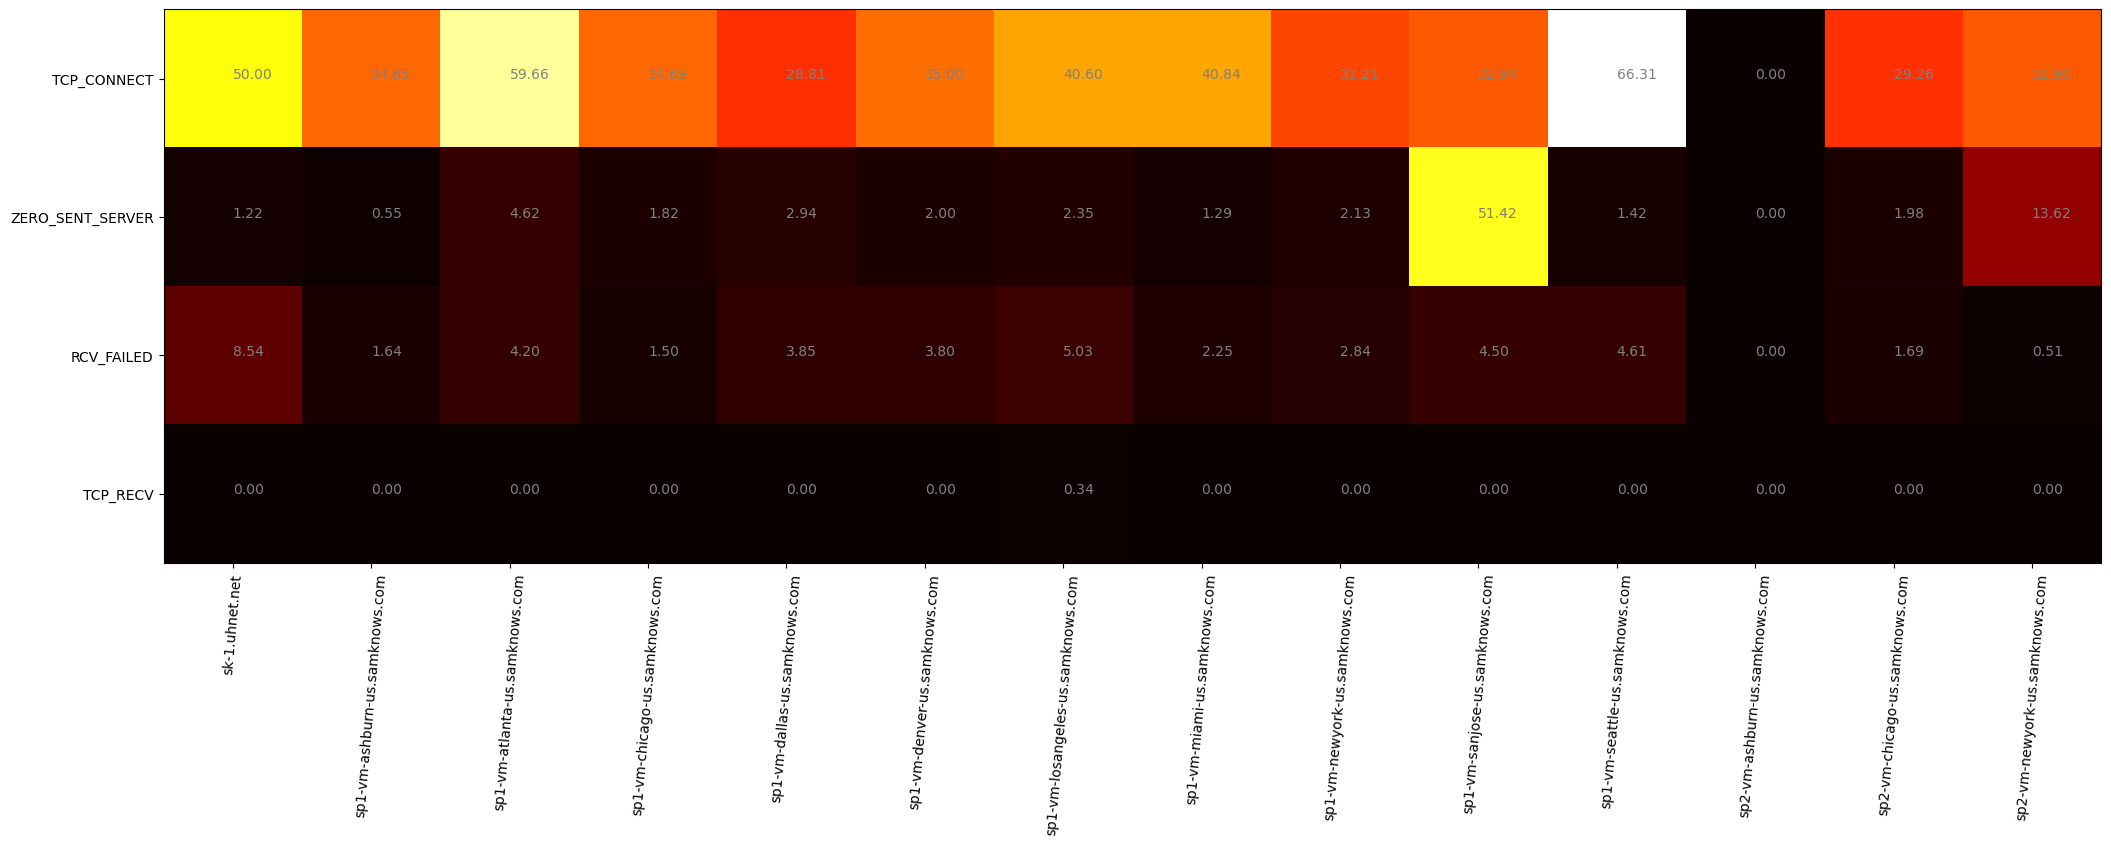

In [12]:
err_types = errors.columns[1:]

targets = errors.to_numpy().transpose()
values = targets[1:].astype(float)
targets = targets[0]

print(len(targets))

fig, ax = plt.subplots(figsize = [25, 10])
ax.imshow(values, cmap="hot")
ax.set_xticks(range(len(targets)), labels=targets, rotation=85)
ax.set_yticks(range(len(err_types)), labels=err_types)

for x in range(len(targets)):
    for y in range(len(err_types)):
        ax.text(x, y, f"{values[y][x]:.2f}", color="gray")

plt.show()

## Data preparation

## Modeling

## Evaluation

## Deployment